# Image segmentation / Сегментация изображений

---

**Name:** Kahla Maha

---




# Segmentation problem

We should solve the problem of binary image segmentation. We must build a network by ourselves, e.g. SegNet or U-net, instead of using a prebuilt or pre-trained network.

**Main Goal:** mean IoU score on the test part of the dataset is at least 0.65.

Tasks
1. Prepare dataset and dataloaders, make sure that normalization and conversions were successful.
2. Set up a model. Write a train function, which shows after each epoch six images from validation dataset, predicted masks, real masks, score and loss function values.
4. Train the model, plot metrics values, loss functions, analyze them and make conclusions.
5. Visualize the result on the test dataset: display 6 random pictures, and predicted and target masks, IoU score between predicted and target mask for each picture.

# Environment setup

Import required modules.

In [ ]:
import numpy as np

import torch
from torch import nn
from torch.nn import functional as F
from torch import optim

from torchvision import models, transforms
from torchsummary import summary

import time
import math
import random

from torch.utils.data import TensorDataset, DataLoader, Dataset
from sklearn.metrics import accuracy_score

import seaborn as sns
from matplotlib import colors, pyplot as plt
from matplotlib import rcParams
from IPython.display import clear_output

from tqdm import tqdm

%matplotlib inline
rcParams['figure.figsize'] = (15,4)
sns.set(style="darkgrid", font_scale=1.4)

In [ ]:
!nvidia-smi

Tue Apr  8 16:48:00 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

For reproducibility of the results, fix seed parameter in random number generators.

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

The GPU can be used to accelerate training. For convenience, let's create a special variable.

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

Let us check that training on GPU is available.

In [ ]:
#Additional Info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_cached(0)/1024**3,1), 'GB')

Tesla T4
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


<ipython-input-5-479eaf52c20e>:6: FutureWarning: `torch.cuda.memory_cached` has been renamed to `torch.cuda.memory_reserved`
  print('Cached:   ', round(torch.cuda.memory_cached(0)/1024**3,1), 'GB')


# Dataset loading

###  From google drive



In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
!unzip -q /content/gdrive/MyDrive/segmentation.zip

# Task 1. Data preparation

Let's take a look at the dataset of road photos and prepare it for training if necessary.

In [ ]:
X = np.load('./x_train.npy')
Y = np.load('./y_train.npy')

print(X.shape)
print(Y.shape)

(3083, 256, 256, 3)
(3083, 256, 256, 1)


To make sure everything is correct, we will draw some images

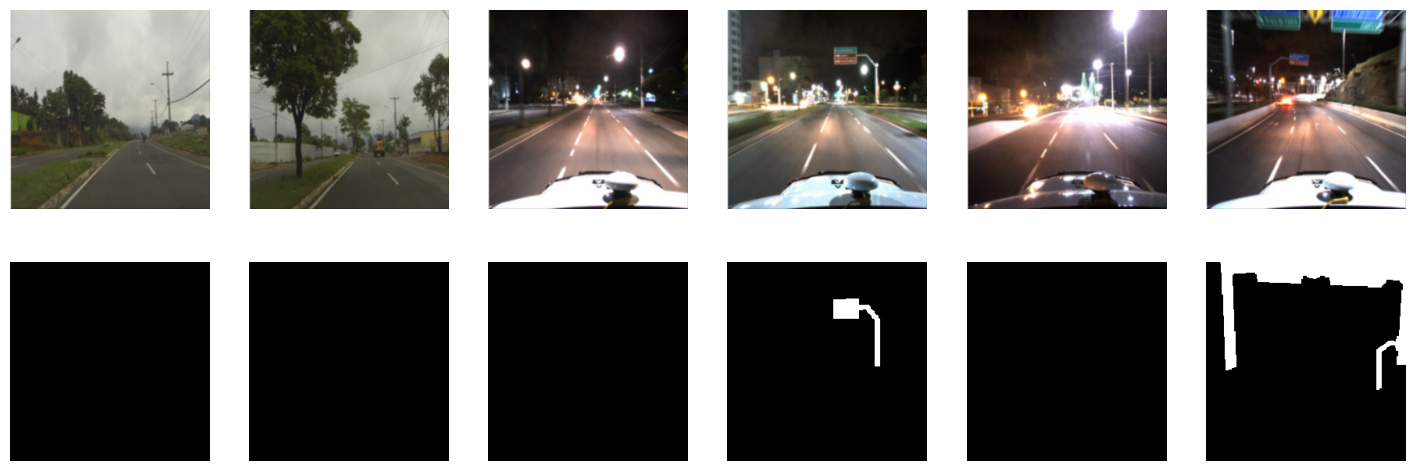

In [ ]:
plt.figure(figsize=(18, 6))
for i in range(6):
    j = 100*i + 1;
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[j])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[j].squeeze(), cmap='gray')
plt.show();

In [ ]:
XX = np.transpose(X[0:3000:2], axes=(0, 3, 1, 2))
YY = np.transpose(Y[0:3000:2], axes=(0, 3, 1, 2))

print(XX.shape)
print(YY.shape)

(1500, 3, 256, 256)
(1500, 1, 256, 256)


Let's check what values are present in the mask

In [ ]:
unique, counts = np.unique(YY, return_counts=True)
print(unique, counts)

[0 1 2] [93829366  4054517   420117]


It contains the following values

* 0 - background
* 1 - road sign
* 2 - crosswalk markings

We will solve the problem of binary segmentation, ie do one mask and for road signs, for this we need to have 1 to road signs and crosswalk markings.


In [ ]:
YY_r = np.where(YY > 0, 1, 0)
unique, counts = np.unique(YY_r, return_counts=True)
print(unique, counts)

[0 1] [93829366  4474634]


Let's check what values are present in the mask now. The number of zeros should not change, and the number of "ones" should be equal to the sum of the number of ones and twos in the masks before the transformation.

In [ ]:
unique, counts = np.unique(YY, return_counts=True)
print(unique, counts)

[0 1 2] [93829366  4054517   420117]


Translate the pixel values of the image into the range [0;1]

In [ ]:
print(np.max(XX), np.min(XX))

255 0


In [ ]:
XXX = np.array(XX / 255, dtype='float32')
YYY = np.array(YY_r, dtype='float32')

print(XXX.shape)
print(YYY.shape)

(1500, 3, 256, 256)
(1500, 1, 256, 256)


Normalizing pixel values

In [ ]:
X_t = torch.FloatTensor(XXX)
Y_t = torch.FloatTensor(YYY)

for x in X_t:
  transforms.functional.normalize(x, (0.485, 0.456, 0.406), (0.229, 0.224, 0.225), inplace=True)

print(X_t.shape)
print(X_t[0])

torch.Size([1500, 3, 256, 256])
tensor([[[ 1.5297,  1.0673,  0.9474,  ...,  1.2385,  1.1872,  0.8618],
         [ 1.8379,  1.3242,  1.1872,  ...,  1.4783,  1.4440,  1.1700],
         [ 1.8379,  1.3242,  1.1872,  ...,  1.4612,  1.4783,  1.2214],
         ...,
         [ 1.8379, -0.2171, -1.1075,  ..., -1.0219, -1.0390, -1.1418],
         [ 1.8379, -0.2171, -1.1247,  ..., -1.0562, -1.0733, -1.1760],
         [ 1.5297, -0.4054, -1.2788,  ..., -1.2445, -1.2445, -1.3302]],

        [[ 1.6933,  1.2556,  1.1506,  ...,  1.4482,  1.3957,  1.0455],
         [ 2.0084,  1.5357,  1.4132,  ...,  1.6933,  1.6583,  1.3782],
         [ 2.0084,  1.5357,  1.4132,  ...,  1.6758,  1.6933,  1.4132],
         ...,
         [ 2.0084, -0.0749, -0.9678,  ..., -0.9328, -0.9503, -1.0553],
         [ 2.0084, -0.0749, -0.9853,  ..., -0.9678, -0.9853, -1.0903],
         [ 1.6933, -0.2850, -1.1604,  ..., -1.1604, -1.1604, -1.2479]],

        [[ 1.9080,  1.4200,  1.2980,  ...,  1.5594,  1.4897,  1.1585],
         [ 2.

In [ ]:
import gc
X = 0
Y = 0
XX = 0
YY =0
XXX = 0
YYY = 0
YY_r =0
gc.collect()

34312

In [ ]:
ix = np.random.choice(len(X_t), len(X_t), False)
tr, val, ts = np.split(ix, [1000, 1250])

In [ ]:
print(len(tr), len(val), len(ts))

1000 250 250


Create dataloaders

In [ ]:
X_train_t = X_t[tr]
Y_train_t = Y_t[tr]
X_val_t = X_t[val]
Y_val_t = Y_t[val]
X_test_t = X_t[ts]
Y_test_t = Y_t[ts]

train_dataset = TensorDataset(X_train_t, Y_train_t)
val_dataset = TensorDataset(X_val_t, Y_val_t)
test_dataset = TensorDataset(X_test_t, Y_test_t)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
loaders = {
    'train': train_dataloader,
    'valid': val_dataloader
}

-----

Below is a function for displaying pictures that have been normalized and stored in tensors.

In [ ]:
def imshow(inp, title=None, plt_ax=plt, default=False):
    """Imshow для тензоров"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt_ax.imshow(inp)
    if title is not None:
        plt_ax.set_title(title)
    plt_ax.grid(False)

Display one of the pictures after normalization to make sure all is correct

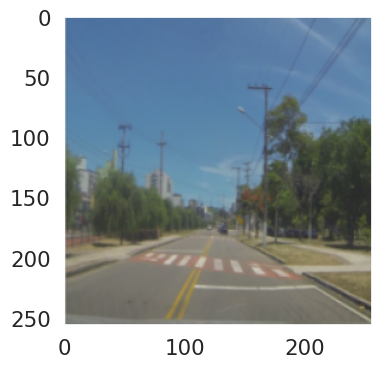

In [ ]:
item = next(iter(train_dataloader))[0]
imshow(item[0])

# Task 2. Set up a model



In [ ]:
class SegNet(nn.Module):
    def __init__(self):
        super().__init__()


        self.enc_conv1 = nn.Sequential(
            nn.Conv2d(in_channels = 3 , out_channels = 64 , kernel_size = 3 , stride = 1 ,padding =  1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64 ,64 , 3 , 1 , 1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.enc_pool1 = nn.MaxPool2d(kernel_size = 2,stride = 2 , return_indices = True)

        self.enc_conv2 = nn.Sequential(
            nn.Conv2d(64 ,128 , 3 , 1 , 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128 ,128 , 3 , 1 , 1),
            nn.BatchNorm2d(128),
            nn.ReLU()

        )
        self.enc_pool2 = nn.MaxPool2d(2,2, return_indices = True)

        self.enc_conv3 = nn.Sequential(
            nn.Conv2d(128 ,256 , 3 , 1 , 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256 ,256 , 3 , 1 , 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256,256 , 3 , 1 , 1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.enc_pool3 = nn.MaxPool2d(2,2, return_indices = True)

        self.enc_conv4 = nn.Sequential(
            nn.Conv2d(256 ,512 , 3 , 1 , 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512 ,512 , 3 , 1 , 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512,512 , 3 , 1 , 1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        self.enc_pool4 = nn.MaxPool2d(2,2, return_indices = True)

        self.enc_conv5 = nn.Sequential(
            nn.Conv2d(512 ,512 , 3 , 1 , 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512 ,512 , 3 , 1 , 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512,512 , 3 , 1 , 1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        self.enc_pool5 = nn.MaxPool2d(2,2, return_indices = True)

        #######################################################  DECODER
        self.dec_conv5 = nn.Sequential(
            nn.Conv2d(512 ,512 , 3 , 1 , 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512 ,512 , 3 , 1 , 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512,512 , 3 , 1 , 1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        self.dec_unpool5 = nn.MaxUnpool2d(2,2)

        self.dec_conv4 = nn.Sequential(
            nn.Conv2d(512 ,512 , 3 , 1 , 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512 ,512 , 3 , 1 , 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512,256 , 3 , 1 , 1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.dec_unpool4 = nn.MaxUnpool2d(2,2)

        self.dec_conv3 = nn.Sequential(
            nn.Conv2d(256 ,256 , 3 , 1 , 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256 ,256 , 3 , 1 , 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256,128 , 3 , 1 , 1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.dec_unpool3 = nn.MaxUnpool2d(2,2)

        self.dec_conv2 = nn.Sequential(
            nn.Conv2d(128 ,128 , 3 , 1 , 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128 ,64 , 3 , 1 , 1),
            nn.BatchNorm2d(64),
            nn.ReLU()

        )
        self.dec_unpool2 = nn.MaxUnpool2d(2,2)

        self.dec_conv1 = nn.Sequential(
            nn.Conv2d(in_channels = 64 , out_channels = 64 , kernel_size = 3 , stride = 1 ,padding =  1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64 ,1 , 3 , 1 , 1)

        )
        self.dec_unpool1 = nn.MaxUnpool2d(2,2)

    def forward(self , x):
        x , indices1 = self.enc_pool1(self.enc_conv1(x))
        x , indices2 = self.enc_pool2(self.enc_conv2(x))
        x , indices3 = self.enc_pool3(self.enc_conv3(x))
        x , indices4 = self.enc_pool4(self.enc_conv4(x))
        x , indices5 = self.enc_pool5(self.enc_conv5(x))

        x = self.dec_conv5(self.dec_unpool5(x,indices5))
        x = self.dec_conv4(self.dec_unpool4(x,indices4))
        x = self.dec_conv3(self.dec_unpool3(x,indices3))
        x = self.dec_conv2(self.dec_unpool2(x,indices2))
        y = self.dec_conv1(self.dec_unpool1(x,indices1))

        return y


## Metric

As a metric we will use the ratio of intersection to union of the masks, more details can be found
[here](https://www.jeremyjordan.me/evaluating-image-segmentation-models/).

The metric according to the definition is calculated as follows
$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$



![alt text](https://www.jeremyjordan.me/content/images/2018/05/target_prediction.png)

![alt text](https://www.jeremyjordan.me/content/images/2018/05/intersection_union.png)

To avoid dividing by 0, a small positive number is added to the numerator and denominator.

In [ ]:
def iou_pytorch(predictions: torch.Tensor, targets: torch.Tensor):
    predictions = predictions.squeeze(1).byte()  # BATCH x 1 x H x W => BATCH x H x W
    targets = targets.squeeze(1).byte()
    SMOOTH = 1e-8

    intersection = (predictions & targets).sum((1,2))  
    union = (predictions | targets).sum((1,2)) 

    iou = (intersection + SMOOTH)/(union + SMOOTH)

    return iou

Let's test the function

In [ ]:
outputs = torch.FloatTensor([[[1., 0.], [0., 1.]], [[1., 0.], [0., 1.]]])
oposite = torch.FloatTensor([[[0., 1.], [1., 0.]], [[0., 1.], [1., 0.]]])
intersected = torch.FloatTensor([[[1., 1.], [0., 1.]], [[1., 1.], [0., 1.]]])

print('iou_pytorch(outputs, outputs)', iou_pytorch(outputs, outputs).mean().item())
print('iou_pytorch(oposite, oposite)', iou_pytorch(oposite, oposite).mean().item())
print('iou_pytorch(intersected, intersected)', iou_pytorch(intersected, intersected).mean().item())

print('iou_pytorch(outputs, oposite)', iou_pytorch(outputs, oposite).mean().item())
print('iou_pytorch(outputs, intersected)', iou_pytorch(outputs, intersected).mean().item())
print('iou_pytorch(oposite, intersected)', iou_pytorch(oposite, intersected).mean().item())

iou_pytorch(outputs, outputs) 1.0
iou_pytorch(oposite, oposite) 1.0
iou_pytorch(intersected, intersected) 1.0
iou_pytorch(outputs, oposite) 2.4999999848063226e-09
iou_pytorch(outputs, intersected) 0.6666666865348816
iou_pytorch(oposite, intersected) 0.25


# Task 3. Train function

Write a learning function that outputs after each epoch of six validation dataset images, predicted masks and real masks, metric and loss function values.

In [ ]:
def plot_example(X_batch, Y_batch, Y_pred, title):
    clear_output(wait=True)

    plt.rcParams["figure.figsize"] = (15,8)
    for k in range(6):
        plt.subplot(3, 6, k+1)
        plt.imshow(np.rollaxis(X_batch[k].numpy(), 0, 3))
        plt.title('Photo')
        plt.axis('off')

        if Y_batch != None:
            plt.subplot(3, 6, k+7)
            plt.imshow(Y_batch[k, 0], cmap='gray')
            plt.title('Mask')
            plt.axis('off')

        if Y_pred != None:
            plt.subplot(3, 6, k+13)
            plt.imshow(Y_pred[k, 0], cmap='gray')
            plt.title('Prediction')
            plt.axis('off')

    plt.suptitle(title)
    plt.show()


In [ ]:
import time
def save_model_wh(name, model):
    ts = time.time()
    path = '/content/gdrive/MyDrive/' + str(ts) + "_" + name + ".mw"
    torch.save(model.state_dict(), path)

In [ ]:
def train(name, model, optimizer, loss_fn, metric_fn, epochs, loaders):
    losses = {"train": [], "valid": []}
    scores = {"train": [], "valid": []}

    for epoch in range(epochs):
        print('* Epoch %d/%d' % (epoch+1, epochs))

        for stage, dataloader in loaders.items():
            avg_loss = 0
            avg_score = 0

            if stage == 'train':
                model.train()
            else:
                model.eval()

            for X_batch, Y_batch in dataloader:
                X_batch = X_batch.to(device)
                Y_batch = Y_batch.to(device)

                if stage == 'train':
                    optimizer.zero_grad()
                    logits = model(X_batch)
                    loss = loss_fn(logits , Y_batch)
                    loss.backward()
                    optimizer.step()

                else:
                    with torch.no_grad():
                        logits = model(X_batch)
                        loss = loss_fn(logits , Y_batch)


                # calculate score and loss to show the user
                Y_pred = torch.round(torch.sigmoid(logits.detach()))
                score = metric_fn(Y_pred, Y_batch).mean().item()

                avg_loss += loss.detach().cpu().numpy() / len(dataloader)
                avg_score += score / len(dataloader)

                # clean GPU memory
                X_batch = X_batch.cpu()
                Y_batch = Y_batch.cpu()
                logits = logits.cpu()
                Y_pred =  Y_pred.cpu()
                torch.cuda.empty_cache()


            losses[stage].append(avg_loss)
            scores[stage].append(avg_score)

        if stage == 'valid':
            if (epoch%10) == 0:
                save_model_wh(name, model)
            plot_example(X_batch , Y_batch , Y_pred , f"epoch {epoch+1}/{epochs} , avg_loss = {avg_loss} , avg_score = {avg_score}")


    return losses, scores

# Task 4. Training

Train the model

In [ ]:
model = SegNet().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)


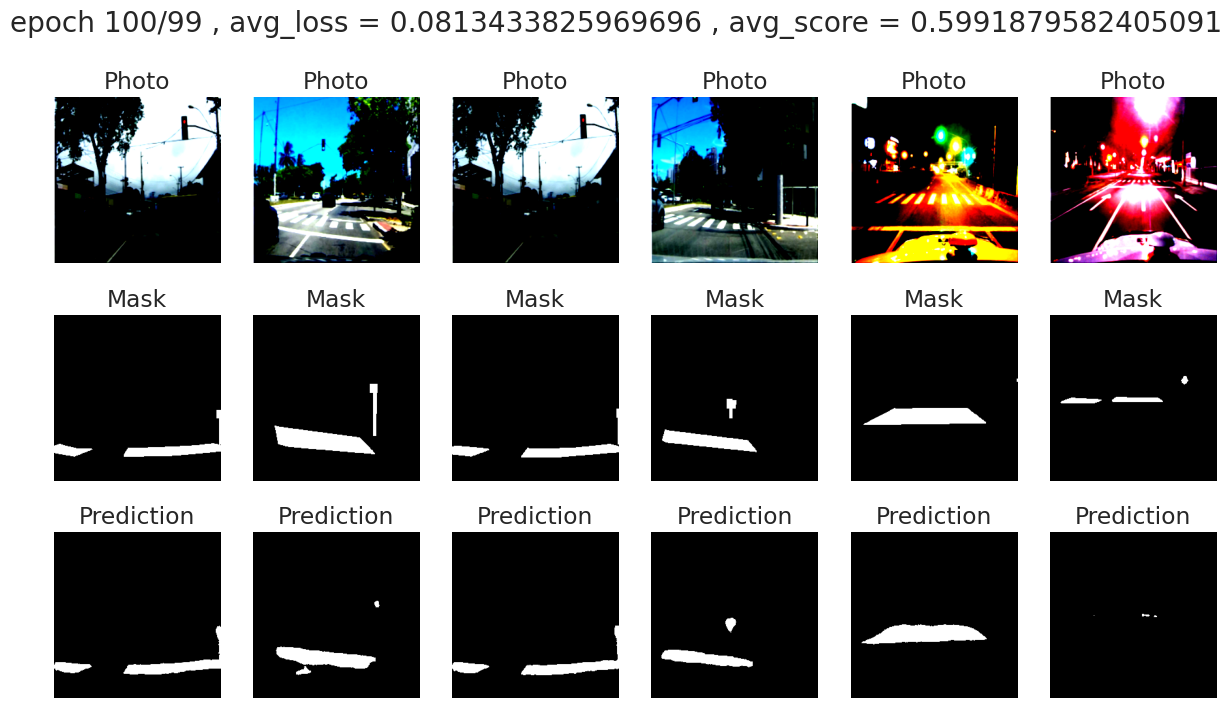

In [ ]:
losses1, scores1 = train("1", model, optimizer, loss_fn, iou_pytorch, epochs=100, loaders= loaders)


Let's plot the value of the metric and the loss function

In [ ]:
def plot_losses_scores(losses, scores, max_epochs):
    fig, axs = plt.subplots(1, 2, constrained_layout=True)
    flat_axs = axs.flatten() # для удобства получим одномерный массив

    flat_axs[0].set_title("Losses")
    flat_axs[0].plot(range(max_epochs), losses['train'], label="Train", linewidth=2)
    flat_axs[0].plot(range(max_epochs), losses['valid'], label="Validation", linewidth=2)
    flat_axs[0].legend()
    flat_axs[0].set_xlabel("Epoch")

    flat_axs[1].set_title("Scores")
    flat_axs[1].plot(range(max_epochs), scores['train'], label="Train", linewidth=2)
    flat_axs[1].plot(range(max_epochs), scores['valid'], label="Validation", linewidth=2)
    flat_axs[1].legend()
    flat_axs[1].set_xlabel("Epoch")

    plt.show()

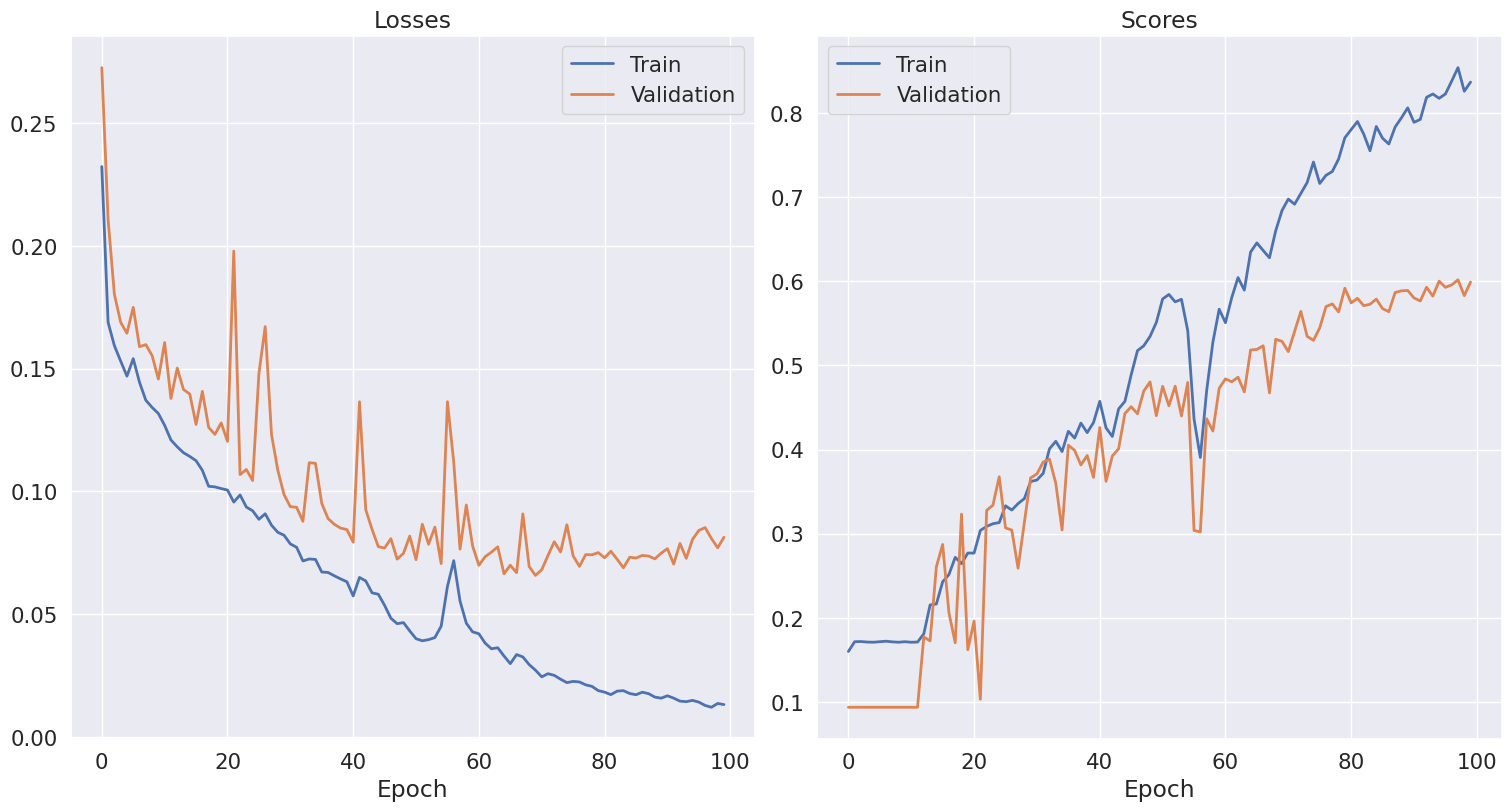

In [ ]:
plot_losses_scores(losses1, scores1, max_epochs=100)

Calculate the IoU metrics on the training, validation, and test datasets, and analyze their values. **Goal**: IoU >= 0.5 on the test part of the dataset

In [ ]:
def testModel( model, loss_fn, metric_fn, dataloader):
    losses = []
    scores = []
    avg_loss = 0
    avg_score = 0

    model.eval()

    for X_batch, Y_batch in dataloader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        with torch.no_grad():
            logits = model(X_batch)
            loss = loss_fn(logits , Y_batch)

        Y_pred = torch.round(torch.sigmoid(logits.detach()))
        score = metric_fn(Y_pred, Y_batch).mean().item()

        avg_loss += loss.detach().cpu().numpy() / len(dataloader)
        avg_score += score / len(dataloader)

        # clean GPU memory
        X_batch = X_batch.cpu()
        Y_batch = Y_batch.cpu()
        logits = logits.cpu()
        Y_pred =  Y_pred.cpu()
        torch.cuda.empty_cache()


    losses.append(avg_loss)
    scores.append(avg_score)

    return losses, scores

In [ ]:
losses11 , scores11 = testModel( model, loss_fn, iou_pytorch, test_dataloader)


In [ ]:
print(losses11,  scores11)

[np.float32(0.08529924)] [0.5217568814754486]


We got a ratio of IoU on the test part of the dataset equals 0.52 . Training loss steadily decreases and flattens out as training progresses. Validation loss decreases initially but then fluctuates significantly after around epoch 20,30. The difference between the curves indicates overfitting at the end of training, which means that the model performs well on training data but doesn't generalize as well. as a solution for this we might use data augmentation.

....

# Task 4. Vizualization

Display 6 random pictures, and predicted and target masks, IoU score between predicted and target mask for each picture.

In [ ]:
model = SegNet().to(device)
model.load_state_dict(torch.load('/content/gdrive/MyDrive/1743164331.3598444_1.mw', weights_only=True))

<All keys matched successfully>

In [ ]:
def plot_example6(X_batch, Y_batch, Y_pred, title, pred_titles = ['Prediction']*6):
    clear_output(wait=True)

    plt.rcParams["figure.figsize"] = (15,8)
    for k in range(6):
        plt.subplot(3, 6, k+1)
        plt.imshow(np.rollaxis(X_batch[k].numpy(), 0, 3))
        plt.title('Photo')
        plt.axis('off')

        if Y_batch != None:
            plt.subplot(3, 6, k+7)
            plt.imshow(Y_batch[k, 0], cmap='gray')
            plt.title('Mask')
            plt.axis('off')

        if Y_pred != None:
            plt.subplot(3, 6, k+13)
            plt.imshow(Y_pred[k, 0], cmap='gray')
            plt.title(pred_titles[k])
            plt.axis('off')

    plt.suptitle(title)
    plt.show()

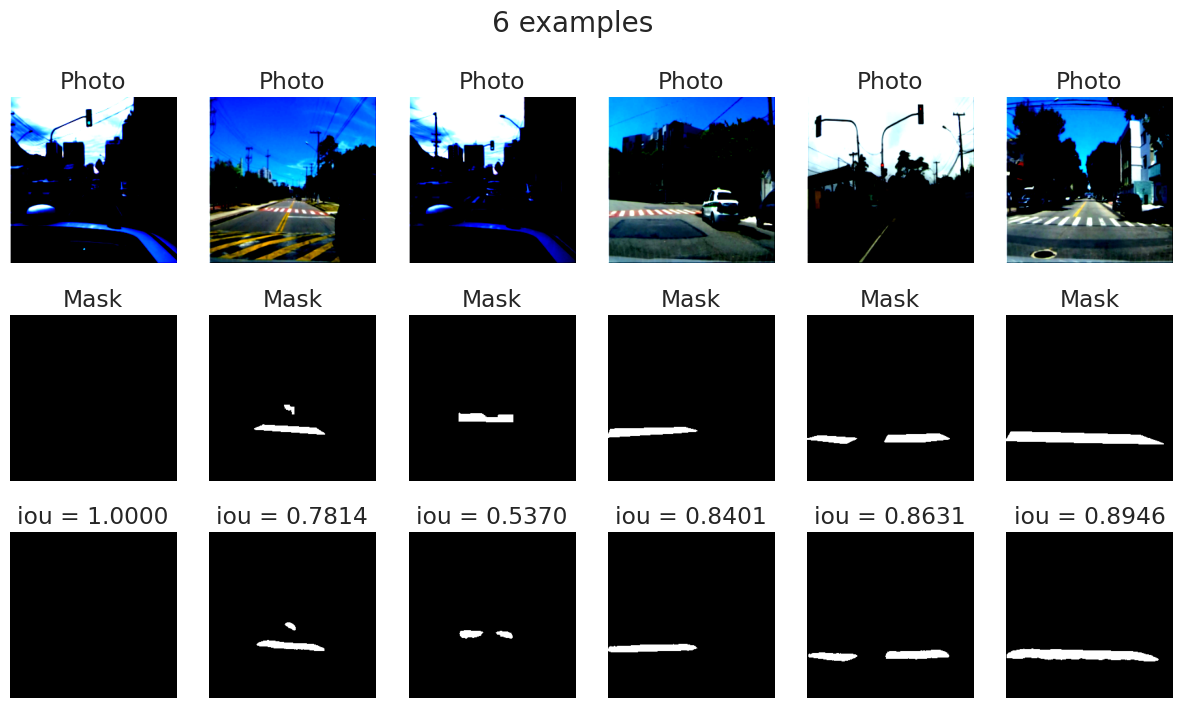

In [ ]:
with torch.no_grad():
    X_batch, Y_batch = next(iter(train_dataloader))
    X_batch = X_batch.to(device)
    logits = model(X_batch)
    logits = logits.cpu()
    X_batch = X_batch.cpu()
    Y_pred = torch.round(torch.sigmoid(logits.detach()))
    ious = iou_pytorch(Y_pred[:6,:,:,:] , Y_batch[:6,:,:,:] )
    pred_titles = ["iou = {:.4f}".format(iou) for iou in ious.tolist()]
    plot_example6(X_batch, Y_batch, Y_pred,  "6 examples" ,pred_titles)

# Task 5. Augmentation

Here another instance of the model must be trained on the augmented data

In [ ]:
class OurOwnDataset(Dataset):
    def __init__(self, data, masks, transforms=None):
        self.data = data
        self.masks = masks
        self.transforms = transforms

        print(f'Found {len(self.data)} items')

    def __getitem__(self, i):
        image = self.data[i]
        mask = self.masks[i]

        image_mask = torch.cat((image , mask) ,dim =0)

        if self.transforms: # to check that the transform is not None
            image_mask = self.transforms(image_mask)

        return image_mask[:3 , : ,: ], image_mask[3: , : ,:]


    def __len__(self):
        return len(self.data)

In [ ]:
from torchvision.transforms import Compose , RandomResizedCrop, RandomRotation, RandomHorizontalFlip

transform = Compose([
    RandomHorizontalFlip(),
    RandomResizedCrop(size=(256, 256), scale=(0.8, 1.2)),
    RandomRotation([-7,7])
])
train_dataset_augmented = OurOwnDataset(X_train_t, Y_train_t, transforms= transform)

train_dataloader_augmented = DataLoader(train_dataset_augmented, batch_size=32)


Found 1000 items


In [ ]:
loaders = {
    'train': train_dataloader_augmented,
    'valid': val_dataloader
}

In [ ]:
modelaug = SegNet().to(device)
optimizer = torch.optim.Adam(modelaug.parameters(), lr = 0.001)
loss_fn = nn.BCEWithLogitsLoss()


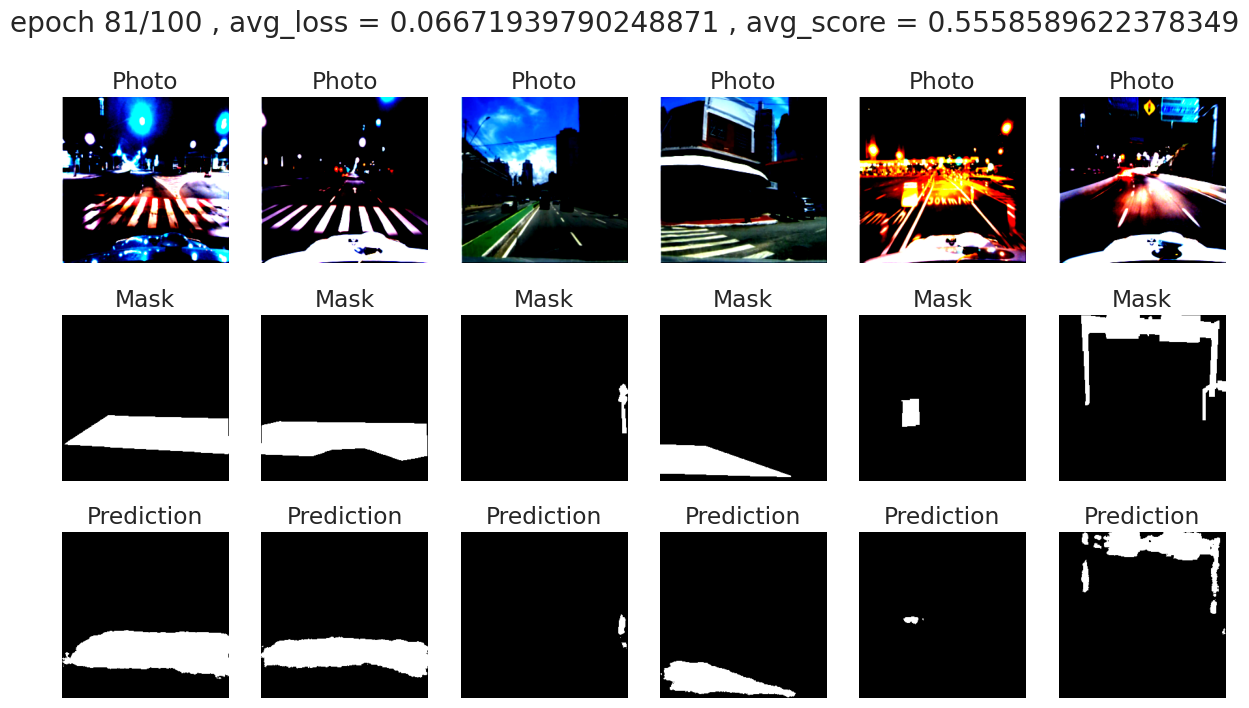

* Epoch 82/100


In [ ]:
lossesF, scoresF = train("augF", modelaug, optimizer, loss_fn, iou_pytorch, epochs=100, loaders= loaders)

In [ ]:
modelaug = SegNet().to(device)
modelaug.load_state_dict(torch.load('/content/gdrive/MyDrive/1744122833.5938692_augF.mw', weights_only=True))
optimizer = torch.optim.Adam(modelaug.parameters(), lr = 0.001)
loss_fn = nn.BCEWithLogitsLoss()

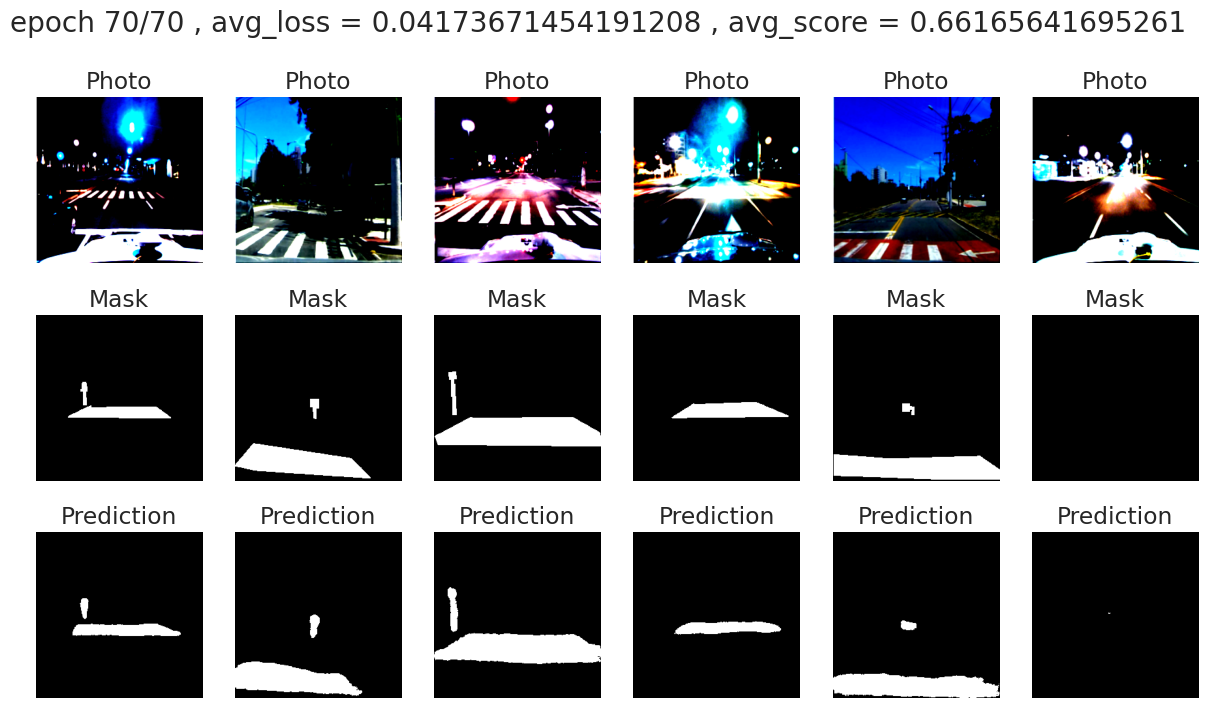

In [ ]:
lossesF, scoresF = train("augF", modelaug, optimizer, loss_fn, iou_pytorch, epochs=70, loaders= loaders)

In [ ]:
lossesF , scoresF = testModel( modelaug, loss_fn, iou_pytorch, test_dataloader)

In [ ]:
print(lossesF,  scoresF)

[np.float32(0.04225919)] [0.6793440356850624]


**Goal**: IoU >= 0.65 on the test part of the dataset

# Task 6. Models training performance comparison

As we see in the first training, there was overfitting but unfortuantely a small mistake happened at the end of the second training with augmentaion that I called (lossesF , scoresF ) with testModel by the same name of the losses list so I lost the values of losses that have been recorded during training before ploting them. Anyway, we got a higher score of IoU on the test part of the dataset when using augmentation. The training with data augmentation has been achieved with two parts because it stopped and I used the trained and saved weights to continue. Things I applied also: decreasing the learning rate, using 1500 samples of the dataset. I also tried many types of transformations and ended up with those in the code.